## 1. Load the pretrained Mask R-CNN model

This section imports the required libraries, defines the configuration, and loads the pretrained **Mask R-CNN Inception-ResNet-v2** model.


In [7]:
# Install packages only if they are not already available

from __future__ import annotations

# Core libraries for file handling, plotting, networking, and model inference.
import io
from pathlib import Path
from typing import Iterable

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import tensorflow as tf
import tensorflow_hub as hub
from PIL import Image

# Five diverse test images used for instance segmentation.
IMAGE_SOURCES: dict[str, list[str]] = {
    "bus_street_scene": [
        "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg",
    ],
    "two_people_same_class": [
        "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/zidane.jpg",
    ],
    "dog_sample_1": [
        "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg",
    ],
    "dog_sample_2": [
        "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg",
    ],
    "portrait_person": [
        "https://storage.googleapis.com/download.tensorflow.org/example_images/grace_hopper.jpg",
    ],
}

# Pretrained Mask R-CNN model from TensorFlow Hub.
TFHUB_MODEL_URL = "https://tfhub.dev/tensorflow/mask_rcnn/inception_resnet_v2_1024x1024/1"

# Output folders for saving images, figures, and CSV tables.
OUTPUT_DIR = Path("outputs")
IMAGES_DIR = OUTPUT_DIR / "images"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

# COCO class labels supported by the pretrained model.
COCO_LABELS: dict[int, str] = {
    1: "person", 2: "bicycle", 3: "car", 4: "motorcycle", 5: "airplane",
    6: "bus", 7: "train", 8: "truck", 9: "boat", 10: "traffic light",
    11: "fire hydrant", 13: "stop sign", 14: "parking meter", 15: "bench",
    16: "bird", 17: "cat", 18: "dog", 19: "horse", 20: "sheep",
    21: "cow", 22: "elephant", 23: "bear", 24: "zebra", 25: "giraffe",
    27: "backpack", 28: "umbrella", 31: "handbag", 32: "tie", 33: "suitcase",
    34: "frisbee", 35: "skis", 36: "snowboard", 37: "sports ball", 38: "kite",
    39: "baseball bat", 40: "baseball glove", 41: "skateboard", 42: "surfboard",
    43: "tennis racket", 44: "bottle", 46: "wine glass", 47: "cup", 48: "fork",
    49: "knife", 50: "spoon", 51: "bowl", 52: "banana", 53: "apple",
    54: "sandwich", 55: "orange", 56: "broccoli", 57: "carrot", 58: "hot dog",
    59: "pizza", 60: "donut", 61: "cake", 62: "chair", 63: "couch",
    64: "potted plant", 65: "bed", 67: "dining table", 70: "toilet",
    72: "tv", 73: "laptop", 74: "mouse", 75: "remote", 76: "keyboard",
    77: "cell phone", 78: "microwave", 79: "oven", 80: "toaster",
    81: "sink", 82: "refrigerator", 84: "book", 85: "clock", 86: "vase",
    87: "scissors", 88: "teddy bear", 89: "hair drier", 90: "toothbrush",
}

def ensure_dirs() -> None:
    # Create all output folders before writing any files.
    for directory in (OUTPUT_DIR, IMAGES_DIR, FIGURES_DIR, TABLES_DIR):
        directory.mkdir(parents=True, exist_ok=True)


def get_class_name(class_id: int) -> str:
    # Map a numeric COCO class id to a readable label.
    return COCO_LABELS.get(int(class_id), f"class_{int(class_id)}")


def load_detector() -> hub.KerasLayer:
    # Load the pretrained instance segmentation model once.
    return hub.load(TFHUB_MODEL_URL)



# Load the pretrained detector once before running inference.
detector = load_detector()
print("Mask R-CNN model loaded successfully.")


Mask R-CNN model loaded successfully.


## 2. Select and load 5 different images

This section defines five diverse test images and loads them from their URLs.  
The set includes crowded scenes and at least one image with multiple objects of the same class.


In [8]:
def load_image_from_url(url_or_urls: str | Iterable[str]) -> np.ndarray:
    # Accept either one URL or a list of fallback URLs.
    candidates = [url_or_urls] if isinstance(url_or_urls, str) else list(url_or_urls)
    headers = {
        # These headers reduce the chance of image hosts blocking the request.
        "User-Agent": "Mozilla/5.0",
        "Accept": "image/avif,image/webp,image/apng,image/*,*/*;q=0.8",
        "Referer": "https://www.google.com/",
    }

    last_error: Exception | None = None
    with requests.Session() as session:
        session.headers.update(headers)
        for url in candidates:
            try:
                response = session.get(url, timeout=60, stream=True)
                response.raise_for_status()
                image = Image.open(io.BytesIO(response.content)).convert("RGB")
                return np.array(image)
            except Exception as exc:
                last_error = exc
                print(f"  Failed to load: {url} -> {exc}")

    raise RuntimeError(f"Could not download any image candidate. Last error: {last_error}") from last_error




loaded_images: dict[str, np.ndarray] = {}

for image_name, image_urls in IMAGE_SOURCES.items():
    print(f"Loading: {image_name}")
    try:
        loaded_images[image_name] = load_image_from_url(image_urls)
        print(f"  Loaded successfully: {loaded_images[image_name].shape}")
    except Exception as exc:
        print(f"  Failed to load {image_name}: {exc}")

print(f"\nTotal loaded images: {len(loaded_images)}")


Loading: bus_street_scene
  Loaded successfully: (1080, 810, 3)
Loading: two_people_same_class
  Loaded successfully: (720, 1280, 3)
Loading: dog_sample_1
  Loaded successfully: (577, 700, 3)
Loading: dog_sample_2
  Loaded successfully: (1213, 1546, 3)
Loading: portrait_person
  Loaded successfully: (600, 512, 3)

Total loaded images: 5


## 3. Perform inference using the model

This section preprocesses each image and runs the pretrained model to obtain raw predictions.


In [9]:
def save_image_copy(image_name: str, image_np: np.ndarray) -> Path:
    # Save the origina image for reference in the output folder.
    path = IMAGES_DIR / f"{image_name}.jpg"
    Image.fromarray(image_np).save(path)
    return path


def preprocess_image(image_np: np.ndarray) -> tf.Tensor:
    # Convert the image to a batch of one because the model expects batched input.
    image_tensor = tf.convert_to_tensor(image_np, dtype=tf.uint8)
    return tf.expand_dims(image_tensor, axis=0)


def run_inference(detector, image_np: np.ndarray) -> dict[str, np.ndarray]:
    # Run the model and squeeze the batch dimension from each output tensor.
    result = detector(preprocess_image(image_np))
    return {key: value.numpy()[0] for key, value in result.items()}



raw_predictions: dict[str, dict[str, np.ndarray]] = {}

for image_name, image_np in loaded_images.items():
    raw_predictions[image_name] = run_inference(detector, image_np)

print(f"Collected raw predictions for {len(raw_predictions)} images.")


Collected raw predictions for 5 images.


## 4. Extract prediction outputs

This section extracts the required outputs from the raw model predictions:
- **Bounding boxes**
- **Class labels**
- **Segmentation masks**


In [10]:
def filter_detections(raw_result: dict[str, np.ndarray], score_threshold: float = 0.5) -> dict[str, np.ndarray | None]:
    # Keep only detections whose confidence is above the selected threshold.
    scores = raw_result["detection_scores"]
    keep = scores >= score_threshold

    detections: dict[str, np.ndarray | None] = {
        "boxes": raw_result["detection_boxes"][keep],
        "classes": raw_result["detection_classes"][keep].astype(np.int32),
        "scores": scores[keep],
        "box_masks": None,
    }

    if "detection_masks" in raw_result:
        detections["box_masks"] = raw_result["detection_masks"][keep]

    return detections

def detections_to_table(image_name: str, detections: dict[str, np.ndarray | None]) -> pd.DataFrame:
    # Convert detections into a tabular format for reporting and export.
    rows: list[dict[str, object]] = []
    for idx, (box, cls, score) in enumerate(
        zip(detections["boxes"], detections["classes"], detections["scores"]),
        start=1,
    ):
        ymin, xmin, ymax, xmax = box.tolist()
        rows.append(
            {
                "image": image_name,
                "instance_id": idx,
                "class_id": int(cls),
                "class_name": get_class_name(int(cls)),
                "score": float(score),
                "ymin": float(ymin),
                "xmin": float(xmin),
                "ymax": float(ymax),
                "xmax": float(xmax),
                "has_mask": detections["box_masks"] is not None,
            }
        )

    return pd.DataFrame(rows)
detections_05: dict[str, dict[str, np.ndarray | None]] = {}

for image_name, raw_result in raw_predictions.items():
    detections_05[image_name] = filter_detections(raw_result, score_threshold=0.5)

detections_df_05 = pd.concat(
    [detections_to_table(name, det) for name, det in detections_05.items()],
    ignore_index=True,
) if detections_05 else pd.DataFrame()

detections_df_05.head(20) if not detections_df_05.empty else pd.DataFrame()


,image,instance_id,class_id,class_name,score,ymin,xmin,ymax,xmax,has_mask
0,bus_street_scene,1,1,person,0.999404,0.362159,0.057476,0.848659,0.308828,True
1,bus_street_scene,2,1,person,0.998628,0.375117,0.827316,0.824827,0.995544,True
2,bus_street_scene,3,1,person,0.998294,0.374220,0.274895,0.799828,0.428720,True
3,bus_street_scene,4,6,bus,0.997358,0.220810,0.013474,0.671141,1.000000,True
4,bus_street_scene,5,1,person,0.887073,0.519569,0.000000,0.810708,0.097355,True
5,two_people_same_class,1,1,person,0.999748,0.275647,0.076870,1.000000,0.867854,True
6,two_people_same_class,2,1,person,0.998561,0.065918,0.572384,0.993474,0.902241,True
7,two_people_same_class,3,32,tie,0.991230,0.611018,0.345085,0.975123,0.405652,True
8,two_people_same_class,4,1,person,0.916539,0.170674,0.377033,1.000000,0.876554,True
9,two_people_same_class,5,1,person,0.913432,0.300858,0.099495,0.995915,0.569388,True


## 5. Visualize the results

This section overlays the predicted masks, draws bounding boxes, and displays class names with confidence scores.


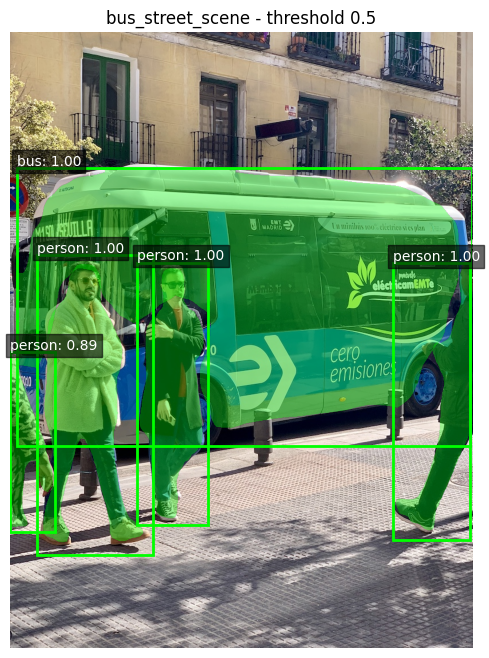

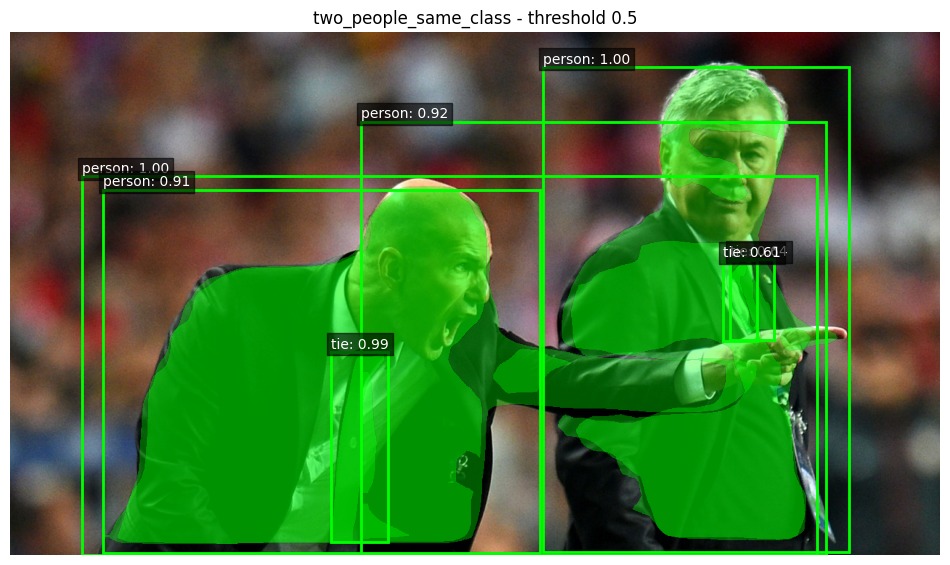

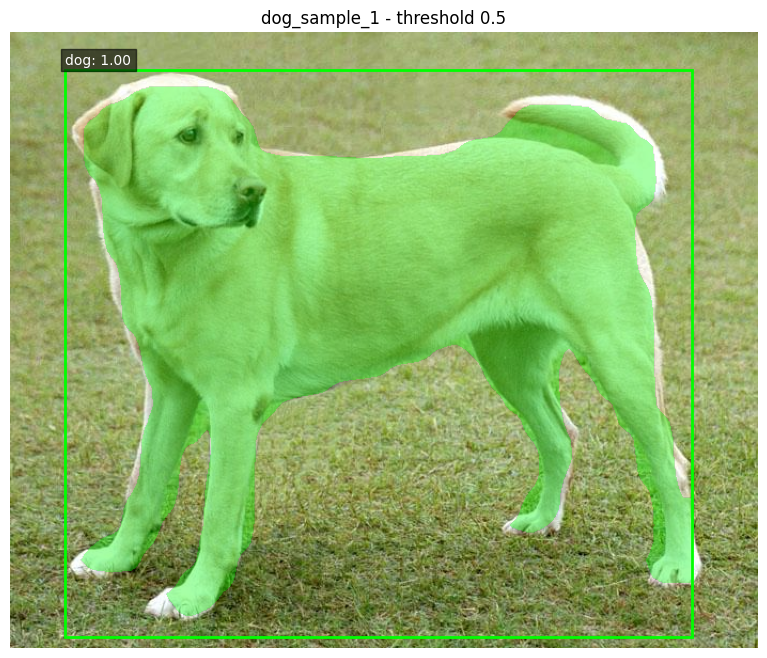

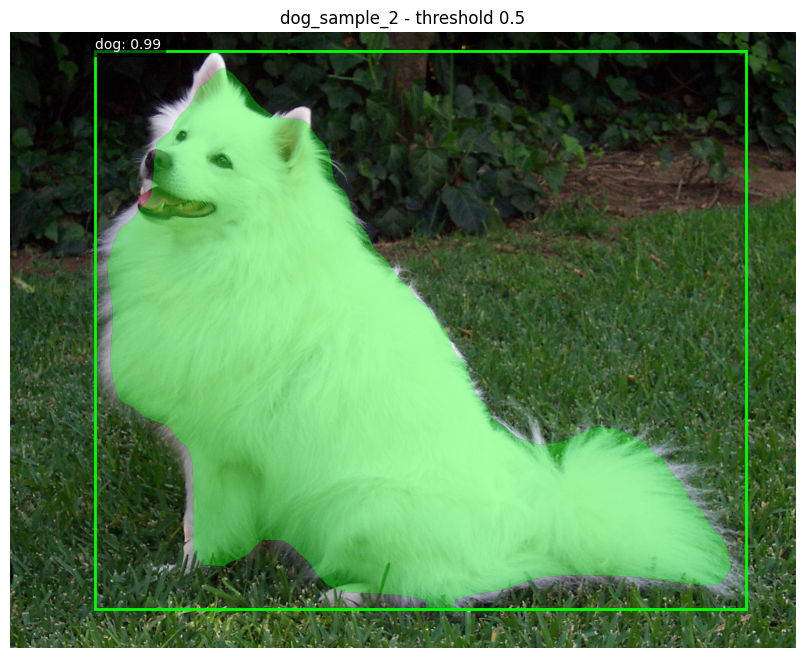

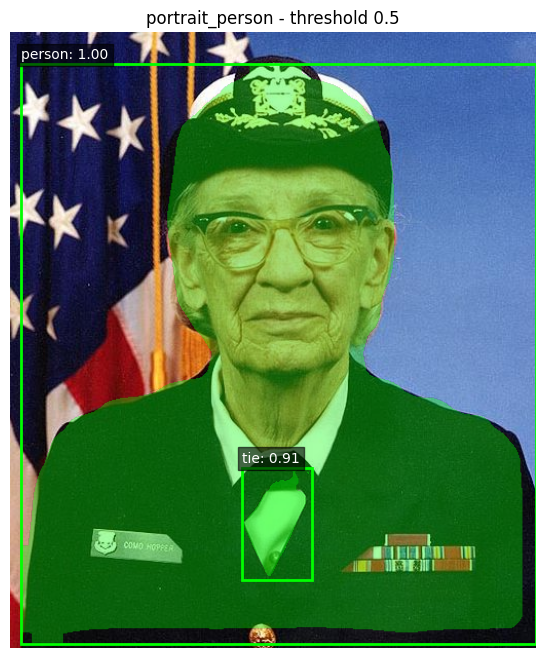

In [11]:
def reframe_box_masks_to_image_masks(
    box_masks: np.ndarray,
    boxes: np.ndarray,
    image_height: int,
    image_width: int,
    threshold: float = 0.5,
) -> np.ndarray:
    # Convert each box-level mask to a full-image binary mask.
    if len(box_masks) == 0:
        return np.empty((0, image_height, image_width), dtype=np.uint8)

    image_masks: list[np.ndarray] = []
    for mask, box in zip(box_masks, boxes):
        ymin, xmin, ymax, xmax = box
        top = max(0, int(round(ymin * image_height)))
        left = max(0, int(round(xmin * image_width)))
        bottom = min(image_height, int(round(ymax * image_height)))
        right = min(image_width, int(round(xmax * image_width)))

        if bottom <= top or right <= left:
            image_masks.append(np.zeros((image_height, image_width), dtype=np.uint8))
            continue

        pil_mask = Image.fromarray((mask * 255).astype(np.uint8))
        resized_mask = pil_mask.resize((right - left, bottom - top), Image.Resampling.BILINEAR)
        resized_mask_np = (np.array(resized_mask) / 255.0) >= threshold

        full_mask = np.zeros((image_height, image_width), dtype=np.uint8)
        full_mask[top:bottom, left:right] = resized_mask_np.astype(np.uint8)
        image_masks.append(full_mask)

    return np.stack(image_masks, axis=0)


def draw_instance_segmentation(
    image_np: np.ndarray,
    detections: dict[str, np.ndarray | None],
    title: str = "Prediction",
    save_path: Path | None = None,
) -> None:
    # Draw the image, masks, bounding boxes, and labels on one figure.
    image_h, image_w = image_np.shape[:2]
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(image_np)
    ax.set_title(title)
    ax.axis("off")

    masks = None
    if detections["box_masks"] is not None and len(detections["boxes"]) > 0:
        masks = reframe_box_masks_to_image_masks(
            detections["box_masks"],
            detections["boxes"],
            image_h,
            image_w,
        )

    for idx, (box, cls, score) in enumerate(
        zip(detections["boxes"], detections["classes"], detections["scores"])
    ):
        ymin, xmin, ymax, xmax = box
        x0 = xmin * image_w
        y0 = ymin * image_h
        width = (xmax - xmin) * image_w
        height = (ymax - ymin) * image_h

        rect = patches.Rectangle(
            (x0, y0),
            width,
            height,
            linewidth=2,
            edgecolor="lime",
            facecolor="none",
        )
        ax.add_patch(rect)

        # Show the predicted class and confidence above each box.
        label = f"{get_class_name(cls)}: {score:.2f}"
        ax.text(
            x0,
            max(0, y0 - 5),
            label,
            fontsize=10,
            bbox={"facecolor": "black", "alpha": 0.6, "pad": 3},
            color="white",
        )

        if masks is not None:
            # Use a semi-transparent green overlay for the instance mask.
            mask = masks[idx]
            overlay = np.zeros((image_h, image_w, 4), dtype=np.float32)
            overlay[..., 1] = mask * 1.0
            overlay[..., 3] = mask * 0.35
            ax.imshow(overlay)

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)

    plt.show()
    plt.close(fig)



ensure_dirs()

for image_name, image_np in loaded_images.items():
    detections = detections_05.get(image_name)
    if detections is None:
        continue

    save_image_copy(image_name, image_np)
    figure_path = FIGURES_DIR / f"{image_name}_threshold_05.png"
    draw_instance_segmentation(
        image_np,
        detections,
        title=f"{image_name} - threshold 0.5",
        save_path=figure_path,
    )


## 6. Experiment with confidence thresholds

This section compares:
- **Default threshold = 0.5**
- **Lower threshold = 0.3**

A lower threshold may detect more objects, but it can also introduce false positives.


In [12]:

def build_summary_table(detections_map: dict[str, dict[str, np.ndarray | None]]) -> pd.DataFrame:
    rows: list[pd.DataFrame] = []
    for image_name, detections in detections_map.items():
        rows.append(detections_to_table(image_name, detections))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


detections_03: dict[str, dict[str, np.ndarray | None]] = {}
for image_name, raw_result in raw_predictions.items():
    detections_03[image_name] = filter_detections(raw_result, score_threshold=0.3)

detections_df_03 = build_summary_table(detections_03)
comparison_df = pd.DataFrame(
    {
        "image": sorted(set(list(detections_05.keys()) + list(detections_03.keys()))),
    }
)

comparison_df["detections_at_0.5"] = comparison_df["image"].map(
    lambda name: len(detections_05.get(name, {}).get("scores", []))
)
comparison_df["detections_at_0.3"] = comparison_df["image"].map(
    lambda name: len(detections_03.get(name, {}).get("scores", []))
)

comparison_df


,image,detections_at_0.5,detections_at_0.3
0,bus_street_scene,5,5
1,dog_sample_1,1,1
2,dog_sample_2,1,1
3,portrait_person,2,3
4,two_people_same_class,7,9
